# Reaching with a redundant muscle-driven arm (MotorNet)

A simple experiment built with [MotorNet](https://www.motornet.org), following the structure of the
official [build-a-plant guide](https://github.com/motornet-org/MotorNet/blob/master/examples/tf/1-build-plant.ipynb).

- **Plant**: MotorNet's built-in planar 2-segment arm (`TwoDofArm`) = upper arm (shoulder joint) +
  forearm (elbow joint).
- **Actuation**: 12 redundant muscles (more muscles than the 2 DOF) — mono-articular shoulder/elbow
  antagonist pairs plus bi-articular muscles that span both joints.
- **Task**: `RandomTargetReach` — reach to random target locations.
- **Controller**: a GRU policy trained end-to-end through the differentiable simulation.

The code is kept deliberately plain.

In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import motornet as mn
from MotorNetUtils.skeleton import NLinkArm

device = torch.device("cpu")
torch.manual_seed(0)
np.random.seed(0)
print("motornet", mn.__version__)

motornet 0.3.0


## 1. Build the plant: a 2-segment arm with many redundant muscles

We use MotorNet's built-in `TwoDofArm` skeleton (shoulder + elbow) and attach muscles by hand with
the generic `add_muscle` method, exactly as in the build-a-plant guide. Each muscle is a path of
fixation points:

- `path_fixation_body`: which bone each point is glued to — `0` = world, `1` = upper arm,
  `2` = forearm.
- `path_coordinates`: `[along_the_bone, perpendicular]` in that bone's frame.

The perpendicular offset is what gives a muscle its moment arm about a joint. We add antagonist
pairs (positive / negative offset), duplicated with slightly different geometry and strength to
create redundancy.

In [ ]:
# Use a simple ReLU muscle so the only required per-muscle parameter is its max force.
#skeleton = mn.skeleton.TwoDofArm()
skeleton = NLinkArm(
    m=[1.9, 1.5, 0.5], l=[0.30, 0.20, 0.10], lg=[0.16, 0.16, 0.07], i=[0.013, 0.020, 0.003],
    pos_lower_bound=np.deg2rad([0, 0, 0]), pos_upper_bound=np.deg2rad([145, 180, 20]),
)
muscle = mn.muscle.ReluMuscle()
effector = mn.effector.Effector(
    skeleton=skeleton,
    muscle=muscle,
    timestep=0.01,
)

muscles = [
    # --- mono-articular SHOULDER (world -> upper arm) ---
    ([0, 1], [[-0.1,  0.0], [0.12, 0.0]], 1000, "flx_01"),
    ([0, 1], [[0.1,  0.0], [0.15, 0.0]],  900, "ext_01"),
    #([0, 1], [[0.00, -0.04], [0.12, 0.0]], 1000, "sho_ext_1"),
    #([0, 1], [[0.00, -0.05], [0.15, 0.0]],  900, "sho_ext_2"),
    ([0, 1, 2], [[0.08,  0.0], [0.32, -.01],  [0.13, 0.0]],  550, "ext_012"),
    # --- mono-articular ELBOW (upper arm -> forearm) ---
    ([1, 2], [[0.10,  0.0], [0.10, 0.0]],  600, "flx_12"),
    # ([1, 2], [[0.26,  0.0], [0.13, 0.0]],  550, "elb_flex_2"),
    # ([1, 2], [[0.28,  0.0], [0.10, 0.0]],  600, "elb_ext_1"),
    # ([1, 2], [[0.26,  0.0], [0.13, 0.0]],  550, "elb_ext_2"),
    ([1, 1, 2], [[0.2,  0.0], [0.32, -.02],  [0.13, 0.0]],  550, "ext_112"),
    # --- bi-articular (world -> forearm, spans both joints) ---
    ([0, 2], [[-0.03,  0.0], [0.10, 0.0]],  500, "flx_02"),
    #([0, 2], [[0.00,  0.04], [0.12, 0.0]],  450, "bi_flex_2"),
    # ([0, 2], [[0.00, -0.03], [0.10, 0.0]],  500, "bi_ext_1"),
    # ([0, 2], [[0.00, -0.04], [0.12, 0.0]],  450, "bi_ext_2"),
]

for fixation, coords, force, name in muscles:
    effector.add_muscle(
        path_fixation_body=fixation,
        path_coordinates=coords,
        max_isometric_force=force,
        name=name,
    )

print("degrees of freedom:", effector.skeleton.dof)
print("number of muscles :", effector.n_muscles)
effector.print_muscle_wrappings()

degrees of freedom: 3
number of muscles : 6
MUSCLE NAME: flx_01
-------------------
n_fixation_points:  2
fixation body:  [0, 1]
coordinates:  [[-0.10000000149011612, 0.0], [0.11999999731779099, 0.0]]
max_isometric_force:  1000


MUSCLE NAME: ext_01
-------------------
n_fixation_points:  2
fixation body:  [0, 1]
coordinates:  [[0.10000000149011612, 0.0], [0.15000000596046448, 0.0]]
max_isometric_force:  900


MUSCLE NAME: ext_012
--------------------
n_fixation_points:  3
fixation body:  [0, 1, 2]
coordinates:  [[0.10000000149011612, 0.0], [0.3199999928474426, -0.009999999776482582], [0.12999999523162842, 0.0]]
max_isometric_force:  550


MUSCLE NAME: flx_12
-------------------
n_fixation_points:  2
fixation body:  [1, 2]
coordinates:  [[0.10000000149011612, 0.0], [0.10000000149011612, 0.0]]
max_isometric_force:  600


MUSCLE NAME: ext_112
--------------------
n_fixation_points:  3
fixation body:  [1, 1, 2]
coordinates:  [[0.20000000298023224, 0.0], [0.3199999928474426, -0.01999999955

### Visualise the plant

Draw the two segments and overlay every muscle path so you can see the layout. Bodies are placed by
forward kinematics (shoulder at the origin; absolute link angle = cumulative sum of joint angles).
A point glued to a bone at `[along, perp]` sits at `joint + R(angle) @ [along, perp]`; world points
(body `0`) are absolute. Colour = muscle group, solid/dashed = flexor/extensor.

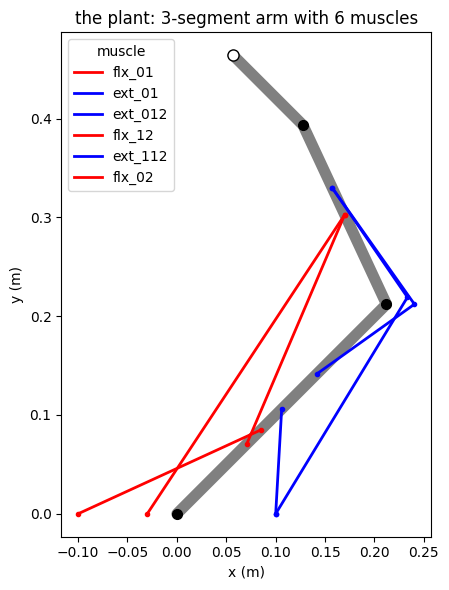

In [27]:
# link lengths read straight from the skeleton -> works for any number of joints
LENGTHS = [getattr(effector.skeleton, f"l{k + 1}") for k in range(effector.skeleton.dof)]


def muscle_color(name, default="0.5"):
    if "flx" in name:
        return "r"
    if "ext" in name:
        return "b"
    return default


def link_points(q):
    """Joint positions [base, ..., tip] for an n-vector of joint angles q."""
    phi = np.cumsum(q)
    pts = [np.array([0.0, 0.0])]
    for k, L in enumerate(LENGTHS):
        pts.append(pts[-1] + L * np.array([np.cos(phi[k]), np.sin(phi[k])]))
    return np.array(pts), phi


def to_world(body, coord, pts, phi):
    """Map a bone-local [along, perp] point on `body` to world coordinates."""
    if body == 0:
        base, ang = np.array([0.0, 0.0]), 0.0
    else:
        base, ang = pts[body - 1], phi[body - 1]
    d = np.array([np.cos(ang), np.sin(ang)])
    p = np.array([-np.sin(ang), np.cos(ang)])
    return base + coord[0] * d + coord[1] * p


def draw_arm(q, ax, alpha=1.0, muscles_on=True):
    pts, phi = link_points(q)
    ax.plot(pts[:, 0], pts[:, 1], "-", color="0.5", lw=8, solid_capstyle="round", alpha=alpha, zorder=1)
    ax.plot(pts[:, 0], pts[:, 1], "o", color='k', ms=7, alpha=alpha, zorder=3)
    ax.plot(pts[-1, 0], pts[-1, 1], "o", color="white", mec="k", ms=8, alpha=alpha, zorder=3)
    if not muscles_on:
        return
    for fixation, coords, _, name in muscles:
        path = np.array([to_world(body, coord, pts, phi) for body, coord in zip(fixation, coords)])
        ax.plot(path[:, 0], path[:, 1], color=muscle_color(name), lw=2, zorder=2, label=name)
        ax.plot(path[:, 0], path[:, 1], ".", color=muscle_color(name), ms=6, zorder=2)


# example posture: an n-vector of joint angles (45/70 deg at the first two joints, rest 0)
example_q = np.zeros(len(LENGTHS))
example_q[:3] = np.deg2rad([45, 70, 20])

fig, ax = plt.subplots(figsize=(6, 6))
draw_arm(example_q, ax)
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title(f"the plant: {len(LENGTHS)}-segment arm with {len(muscles)} muscles")
ax.legend(title="muscle", loc="upper left")
plt.tight_layout()
plt.show()

### Optional: a general n-link arm (to add more segments)

MotorNet's `TwoDofArm` is fixed at 2 joints. To add a segment (e.g. a wrist) you need a custom
`Skeleton`. The class below is a plain planar arm with **any number of links** — it reproduces
`TwoDofArm` exactly for `n = 2` (validated to ~1e-6), so it is a drop-in replacement. Defining it
does **not** change the 2-DOF plant above; to actually use it, set `skeleton = NLinkArm(...)` in the
build cell, e.g.:

```python
skeleton = NLinkArm(
    m=[1.9, 1.5, 0.5], l=[0.31, 0.27, 0.15], lg=[0.16, 0.16, 0.07], i=[0.013, 0.020, 0.003],
    pos_lower_bound=np.deg2rad([0, 0, -70]), pos_upper_bound=np.deg2rad([140, 160, 70]),
)
# then add muscles with fixation bodies 0..3 (3 = the new hand segment),
# and extend LENGTHS / GROUP_COLOR accordingly for the plots.
```

## 2. Wrap the plant in a reaching task

`RandomTargetReach` resets the arm to a random posture and asks it to reach a random target
location. Each `step` advances the muscle-driven arm forward in time.

In [154]:
env = mn.environment.RandomTargetReach(effector=effector, max_ep_duration=1.0)

obs_dim = env.observation_space.shape[0]
n_muscles = env.n_muscles
print("observation dim:", obs_dim)
print("action dim (muscles):", n_muscles)

observation dim: 14
action dim (muscles): 5


## 3. Controller: a GRU policy

The policy maps the observation (target location + delayed proprioception) to a muscle activation
command at every time step. We use MotorNet's `PolicyGRU`, which already follows the design from the
official [train-a-network example](https://github.com/motornet-org/MotorNet/blob/master/examples/4-train-net.ipynb):

- a single **GRU** layer + linear readout with a **sigmoid** output, so commands are bounded to
  `[0, 1]` (the valid muscle-activation range);
- **Xavier** init on the input/readout weights and **orthogonal** init on the recurrent weights;
- the readout **bias initialised to −5**, so the arm starts each run with near-zero force and learns
  to push up from there (a big help for stable training).

In [ ]:
policy = mn.policy.PolicyGRU(obs_dim, 128, n_muscles, device=device)
optimizer = torch.optim.Adam(policy.parameters(), lr=1e-3)

n_dof = effector.skeleton.dof

def run_episode(batch_size):
    """Roll out one batch of reaches; return hand-xy, target-xy, actions, joint angles."""
    h = policy.init_hidden(batch_size=batch_size)
    obs, info = env.reset(options={"batch_size": batch_size})
    xy, tg, acts, joints = [], [], [], []
    terminated = False
    while not terminated:
        action, h = policy(obs, h)
        obs, _, terminated, _, info = env.step(action=action)
        xy.append(info["states"]["fingertip"][:, None, :])         # hand position
        tg.append(info["goal"][:, None, :])                        # target position
        acts.append(action[:, None, :])
        joints.append(info["states"]["joint"][:, None, :n_dof])    # joint angles (all dof)
    return (torch.cat(xy, dim=1), torch.cat(tg, dim=1),
            torch.cat(acts, dim=1), torch.cat(joints, dim=1))

## 4. Train

Loss = mean distance of the hand (`fingertip`) to the target over the trajectory, plus a small
penalty on muscle activation (effort). The whole simulation is differentiable, so we backprop
straight through it. Following the MotorNet example, we **clip the gradient norm to 1** each step —
this is the single change that most improves stability of backprop-through-time here.

In [156]:
batch_size = 32
n_batches = 20000          # the MotorNet example trains for ~6000; raise for cleaner reaches
losses = []

for b in range(n_batches):
    xy, tg, acts, _ = run_episode(batch_size)
    pos_loss = torch.mean(torch.sum(torch.abs(xy - tg), dim=-1))
    effort = 1e-3 * torch.mean(torch.sum(acts ** 2, dim=-1))
    loss = pos_loss + effort

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=1.0)  # stabilises training
    optimizer.step()

    losses.append(loss.item())
    if (b + 1) % 50 == 0:
        print(f"batch {b + 1:4d} | loss {loss.item():.4f} (pos {pos_loss.item():.4f})")

batch   50 | loss 0.3563 (pos 0.3563)
batch  100 | loss 0.3342 (pos 0.3341)
batch  150 | loss 0.3776 (pos 0.3776)
batch  200 | loss 0.3203 (pos 0.3203)
batch  250 | loss 0.3000 (pos 0.3000)
batch  300 | loss 0.4050 (pos 0.4043)
batch  350 | loss 0.3550 (pos 0.3548)
batch  400 | loss 0.3586 (pos 0.3579)
batch  450 | loss 0.3952 (pos 0.3938)
batch  500 | loss 0.2902 (pos 0.2901)
batch  550 | loss 0.2934 (pos 0.2932)
batch  600 | loss 0.3031 (pos 0.3028)
batch  650 | loss 0.3175 (pos 0.3170)
batch  700 | loss 0.3704 (pos 0.3702)
batch  750 | loss 0.3095 (pos 0.3093)
batch  800 | loss 0.3119 (pos 0.3117)
batch  850 | loss 0.3456 (pos 0.3455)
batch  900 | loss 0.3326 (pos 0.3323)
batch  950 | loss 0.3004 (pos 0.3003)
batch 1000 | loss 0.2892 (pos 0.2890)
batch 1050 | loss 0.2475 (pos 0.2474)
batch 1100 | loss 0.3496 (pos 0.3491)
batch 1150 | loss 0.2756 (pos 0.2753)
batch 1200 | loss 0.3314 (pos 0.3310)
batch 1250 | loss 0.2378 (pos 0.2377)
batch 1300 | loss 0.2961 (pos 0.2958)
batch 1350 |

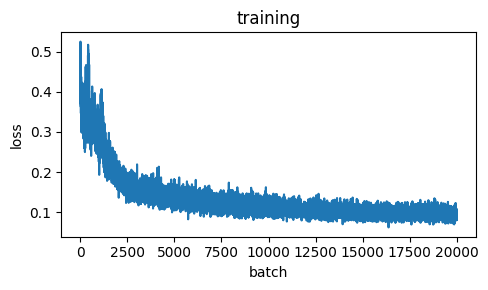

In [157]:
plt.figure(figsize=(5, 3))
plt.plot(losses)
plt.xlabel("batch") 
plt.ylabel("loss")
plt.title("training")
plt.tight_layout()
plt.show()

## 5. Look at the learned reaches

Run a fresh batch and plot the hand paths (start ○, target ×).

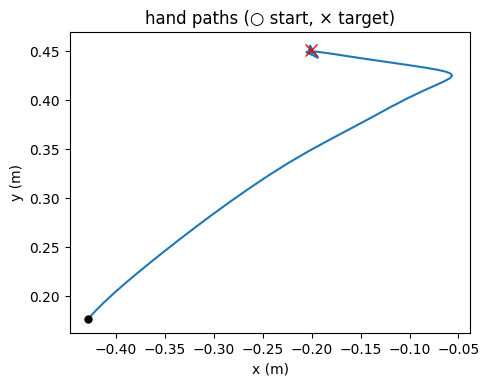

In [161]:
with torch.no_grad():
    xy, tg, acts, joints = run_episode(batch_size=1)
xy, tg = xy.numpy(), tg.numpy()

plt.figure(figsize=(5, 5))
for i in range(xy.shape[0]):
    plt.plot(xy[i, :, 0], xy[i, :, 1], lw=1.5)
    plt.plot(xy[i, 0, 0], xy[i, 0, 1], "o", color="k", ms=5)        # start
    plt.plot(tg[i, -1, 0], tg[i, -1, 1], "x", color="r", ms=9)      # target
plt.gca().set_aspect("equal")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("hand paths (○ start, × target)")
plt.tight_layout()
plt.show()

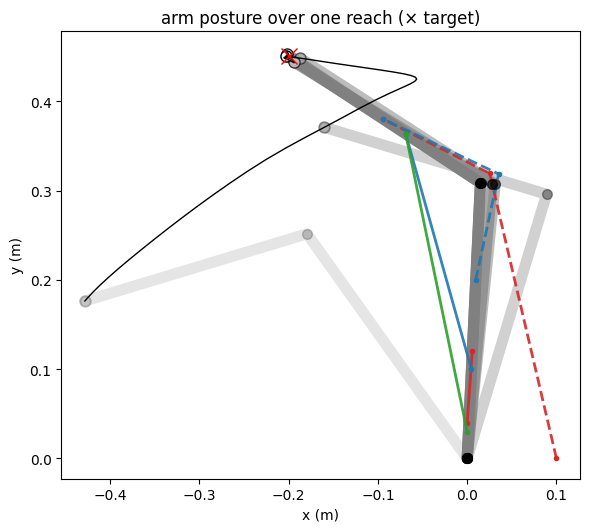

In [162]:
# Arm posture along one reach: faint early postures -> bold final posture.
joints_np = joints[0].numpy()
T = joints_np.shape[0]
frames = np.linspace(0, T - 1, 6).astype(int)

fig, ax = plt.subplots(figsize=(6, 6))
for j, t in enumerate(frames):
    a = 0.2 + 0.8 * j / (len(frames) - 1)
    draw_arm(joints_np[t], ax, alpha=a, muscles_on=(t == frames[-1]))
ax.plot(xy[0, :, 0], xy[0, :, 1], "-", color="k", lw=1, zorder=4)
ax.plot(tg[0, -1, 0], tg[0, -1, 1], "x", color="r", ms=11, zorder=5)
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("arm posture over one reach (× target)")
plt.tight_layout()
plt.show()

In [ ]:
# Muscle activations over time for one reach (shows the redundant control).
a = acts[0].numpy()
plt.figure(figsize=(7, 4))
for m in range(a.shape[1]):
    plt.plot(a[:, m], color=muscle_color(effector.muscle_name[m]),
             lw=1.2, label=effector.muscle_name[m])
plt.xlabel("time step")
plt.ylabel("activation")
plt.title("muscle activations (one reach)")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()